In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.pipeline import Pipeline
from datetime import datetime
from timeit import default_timer as timer

from sklearn.preprocessing import  MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV,StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC, OneClassSVM
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (accuracy_score, recall_score,f1_score,RocCurveDisplay,roc_auc_score, \
PrecisionRecallDisplay, precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay, confusion_matrix)

from sklearn.metrics import auc # Import auc for AUPRC
from sklearn.metrics import make_scorer, recall_score

**Load the saved data from main notebook pkl files**

In [7]:
import pickle
import os

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/saved_model_components_backup'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Load the train/test splits
with open(os.path.join(save_dir, 'X_train.pkl'), 'rb') as f:
    loaded_X_train = pickle.load(f)
with open(os.path.join(save_dir, 'X_test.pkl'), 'rb') as f:
    loaded_X_test = pickle.load(f)
with open(os.path.join(save_dir, 'y_train.pkl'), 'rb') as f:
    loaded_y_train = pickle.load(f)
with open(os.path.join(save_dir, 'y_test.pkl'), 'rb') as f:
    loaded_y_test = pickle.load(f)
print("Loaded train/test data.")

# Load the dictionary of best models
with open(os.path.join(save_dir, 'best_models.pkl'), 'rb') as f:
    loaded_best_models = pickle.load(f)
print(f"Loaded best models from {os.path.join(save_dir, 'best_models.pkl')}")

print("\nVerification of loaded data types:")

print(f"Type of loaded_X_train: {type(loaded_X_train)}")
print(f"Type of loaded_best_models: {type(loaded_best_models)}")


Loaded train/test data.
Loaded best models from /content/drive/MyDrive/saved_model_components_backup/best_models.pkl

Verification of loaded data types:
Type of loaded_X_train: <class 'pandas.core.frame.DataFrame'>
Type of loaded_best_models: <class 'dict'>


In [9]:
X_train=loaded_X_train
X_test=loaded_X_test
y_train=loaded_y_train
y_test=loaded_y_test
X=pd.concat([X_train,X_test])
y=pd.concat([y_train,y_test])

X.shape,y.shape

((283726, 30), (283726,))

###**Isolation Forest**
Credit card fraudulent transactions are a rare phenomenon in the world of  monetary transactions. Hence, in an otherwise dataset of normal transactions , they can be considered anomalies .

**Unsupervised machine learning called Isolation Forest** tries an ensemble approach by fitting multiple isolation trees to detect outliers. The logic is that they would be easily identifiable within a few depths once the trees are constructed. The number of splits required to isolate a sample is equivalent to the path length root node to terminating node.  The average of this path length gives a measure of normality for datapoints and the decision function to consider(isolate) anomalies.

The mathematical formula is a function of the tree depth and expected value of the data point (observation)
**pow(2, neg(E(h(x)))/c(m))**

*E(h(x))= Expected value of x (avg path length of observation x )*

*c(m) - Expected path lengtgh required to isolate a single observation when there are m data points.*

**Isolation Forest relies on random isolation**
It does not need the entire dataset per tree
Smaller subsamples improve randomness and speed hence we would be limiting max_samples to 256 only initially .

IsolationForest predictions are:

1 → normal

-1 → anomaly

In [4]:
#IsolationForest predictions are:
# 1 → normal
# -1 → anomaly  hence we would need to define custom scoring for grid search in order to map back to the [0,1] for legit vs fraud.
from sklearn.metrics import make_scorer
# We will define a custom scorer for recall that handles Isolation Forest's -1/1 predictions

def anomaly_recall(y_true, y_pred):
    y_pred_converted = (y_pred == -1).astype(int) # Convert -1 (anomaly) to 1, 1 (normal) to 0
    return recall_score(y_true, y_pred_converted)

anomaly_recall_scorer = make_scorer(anomaly_recall)

### **Isolation Forest with Default Settings**

Given the current results, let's train and evaluate an `IsolationForest` model using its default parameters to establish a baseline without hyperparameter tuning. We will use `contamination='auto'` as a common practice for anomaly detection, which estimates the proportion of outliers in the data.

Metrics for Isolation Forest with Default Settings:
Test Accuracy: 0.9628
Test Precision: 0.0355
Test Recall: 0.8105
Test F1-Score: 0.0680

Confusion Matrix for Test Data (Default Isolation Forest):


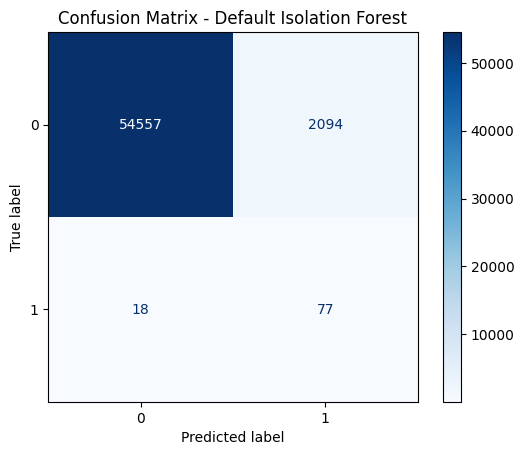

In [23]:
# Initialize Isolation Forest with default settings (or common defaults)
# apply scaling by creating a pipeline
ilf_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('ilf', IsolationForest(contamination='auto', random_state=42))
])

# Fit the model on the training data
ilf_pipe.fit(loaded_X_train)

# Predict anomalies

# Make predictions on the test data
default_y_pred_test = ilf_pipe.predict(loaded_X_test)

# Make predictions on the train data
default_y_pred_train = ilf_pipe.predict(loaded_X_train)

# Convert Isolation Forest predictions to match y_true (1 for anomaly, 0 for normal)
default_y_pred_converted = (default_y_pred_test == -1).astype(int)

# Calculate metrics
default_accuracy = accuracy_score(loaded_y_test, default_y_pred_converted)
default_precision = precision_score(loaded_y_test, default_y_pred_converted)
default_recall = recall_score(loaded_y_test, default_y_pred_converted)
default_f1 = f1_score(loaded_y_test, default_y_pred_converted)

print('Metrics for Isolation Forest with Default Settings:')
print(f'Test Accuracy: {default_accuracy:.4f}')
print(f'Test Precision: {default_precision:.4f}')
print(f'Test Recall: {default_recall:.4f}')
print(f'Test F1-Score: {default_f1:.4f}')

# Display Confusion Matrix
print('\nConfusion Matrix for Test Data (Default Isolation Forest):')
default_cm = confusion_matrix(loaded_y_test, default_y_pred_converted)
default_cmd_display = ConfusionMatrixDisplay(confusion_matrix=default_cm, display_labels=[0, 1])
default_cmd_display.plot(cmap='Blues')
plt.title('Confusion Matrix - Default Isolation Forest')
plt.show()

In [24]:
#Print the anomaly scores from the predictions
anomaly_scores_train=ilf_pipe.decision_function(loaded_X_train)
anomaly_scores_test=ilf_pipe.decision_function(loaded_X_test)

print(f"Anomaly scores for train data: {anomaly_scores_train}")
print(f"Anomaly scores for test data: {anomaly_scores_test}")

Anomaly scores for train data: [0.08886516 0.09046864 0.07179241 ... 0.10826285 0.12068961 0.06816781]
Anomaly scores for test data: [0.1390903  0.12189122 0.04998365 ... 0.13630887 0.12244408 0.09506889]


In [25]:
#  Print the default params of this default model
ilf_pipe.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()),
  ('ilf', IsolationForest(random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'ilf': IsolationForest(random_state=42),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'ilf__bootstrap': False,
 'ilf__contamination': 'auto',
 'ilf__max_features': 1.0,
 'ilf__max_samples': 'auto',
 'ilf__n_estimators': 100,
 'ilf__n_jobs': None,
 'ilf__random_state': 42,
 'ilf__verbose': 0,
 'ilf__warm_start': False}

### Analyzing Anomaly Scores By Threshold

The low recall suggests that the Isolation Forest model, with its current configuration, is not effectively capturing all the fraudulent transactions. We can investigate this further by examining the distribution of the `anomaly_scores_test` for both normal (class 0) and fraudulent (class 1) instances in the test set. A good separation in these distributions would indicate that a manual threshold adjustment might significantly improve recall.

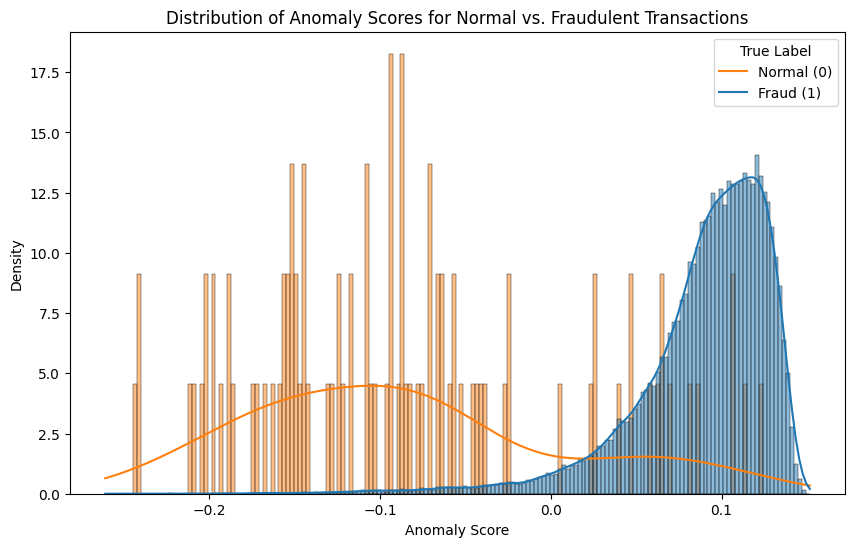

In [26]:
# Create a DataFrame for easier plotting
anomaly_df = pd.DataFrame({
    'anomaly_score': anomaly_scores_test,
    'true_label': loaded_y_test
})

# Plotting the distribution of anomaly scores for normal vs. anomaly
plt.figure(figsize=(10, 6))
sns.histplot(data=anomaly_df, x='anomaly_score', hue='true_label', kde=True, stat='density', common_norm=False)
plt.title('Distribution of Anomaly Scores for Normal vs. Fraudulent Transactions')
plt.xlabel('Anomaly Score')
plt.ylabel('Density')
plt.legend(title='True Label', labels=['Normal (0)', 'Fraud (1)'])
plt.show()

In [ ]:
# It can be seen above that fraud transactions do get isolated to a large extent on basis of decision threshold but still there is an overlap with normal ones.

### Grid search using cv on Isolation Forest parameters.

Tuning Isolation Forest using RandomizedSearchCV...at  2026-06-02 10:19:58.885427  UTC
Best parameters: {'if__n_estimators': 800, 'if__max_samples': 0.5, 'if__max_features': 0.5, 'if__contamination': 0.03}
Best score: 0.8439153439153438
Train time: 1434.6507765590004
Test Accuracy: 0.9701
Test Precision: 0.0439
Test Recall: 0.8105
Test F1-Score: 0.0832

Confusion Matrix for Test Data:


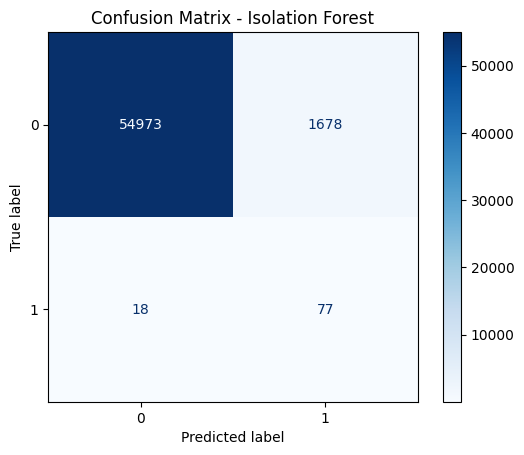

In [10]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) #  K-Fold cross validation
param_grid = {
    "if__contamination": [0.02,0.03],  # Slightly wider range for random search
    "if__n_estimators": [700,800], # Explore more n_estimators
    "if__max_samples": [0.5,1.0],  # Explore different sample proportions
    "if__max_features": [0.5, 0.7,0.9] # Explore different feature proportions
}

if_results_cv= []
best_models={}
# use the pipeline for grid search
iclf_pipe=Pipeline([
    ('scaler', MinMaxScaler()),# scale the data as IF does use distance in its calculation
    ('if', IsolationForest(random_state=42))
])

start_time = timer()
print(f"Tuning Isolation Forest using RandomizedSearchCV...at ", datetime.now(),  " UTC")

# Changed from GridSearchCV to RandomizedSearchCV because IF works on the principle of extreme randomness in features and samples unlike DT which use CE or gini index
# also would help converge faster
grid = RandomizedSearchCV(iclf_pipe, param_grid, scoring=anomaly_recall_scorer, cv=cv, n_iter=10, random_state=42, n_jobs=-1) ## use custom anomaly_recall_scorer due to mapping difference in IF .
grid.fit(loaded_X_train, loaded_y_train)
train_time_model = timer()- start_time
best_models["Isolation Forest"] = grid.best_estimator_

# Calculate the predictions and scores using best est
y_tr_pred = grid.best_estimator_.predict(loaded_X_train)
y_te_pred = grid.best_estimator_.predict(loaded_X_test)

# Compute the anomaly scores from the predictions
anomaly_scores_train = -grid.best_estimator_.decision_function(loaded_X_train)
anomaly_scores_test = -grid.best_estimator_.decision_function(loaded_X_test)

# Convert Isolation Forest predictions to match y_true (1 for anomaly, 0 for normal)
y_te_pred_converted = (y_te_pred == -1).astype(int)

# Store results like accuracy , train time , best params , best score and also  precision , recall, F1-score , accuracy for train and test data
accuracy=accuracy_score(loaded_y_test, y_te_pred_converted)
precision=precision_score(loaded_y_test, y_te_pred_converted)
recall=recall_score(loaded_y_test, y_te_pred_converted)
f1=f1_score(loaded_y_test, y_te_pred_converted)

# Print out the above stats
print(f"Best parameters: {grid.best_params_}")
print(f"Best score: {grid.best_score_}")
print(f"Train time: {train_time_model}")

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")


# Display Confusion Matrix
print("\nConfusion Matrix for Test Data:")
cm = confusion_matrix(loaded_y_test, y_te_pred_converted)
cmd_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cmd_display.plot(cmap='Blues')
plt.title('Confusion Matrix - Isolation Forest')
plt.show()

In [11]:
grid.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()),
  ('if',
   IsolationForest(contamination=0.03, max_features=0.5, max_samples=0.5,
                   n_estimators=800, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'if': IsolationForest(contamination=0.03, max_features=0.5, max_samples=0.5,
                 n_estimators=800, random_state=42),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'if__bootstrap': False,
 'if__contamination': 0.03,
 'if__max_features': 0.5,
 'if__max_samples': 0.5,
 'if__n_estimators': 800,
 'if__n_jobs': None,
 'if__random_state': 42,
 'if__verbose': 0,
 'if__warm_start': False}

In [12]:
# After performing grid search randomized , grid.best_estimator_ was found to be the better model with same detection of TP and FN but much lesser FPs .
# Change the code below to use the grid searched best estimator
df_default_if_results = pd.DataFrame({
    'Model': ['GS Isolation Forest'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1],
    'Train Time': [train_time_model],
    'Best Params': [grid.best_params_],
    'Best Score': [grid.best_score_]
})

display(df_default_if_results)

,Model,Accuracy,Precision,Recall,F1-Score,Train Time,Best Params,Best Score
0,GS Isolation Forest,0.970112,0.043875,0.810526,0.083243,1434.650777,"{'if__n_estimators': 800, 'if__max_samples': 0...",0.843915


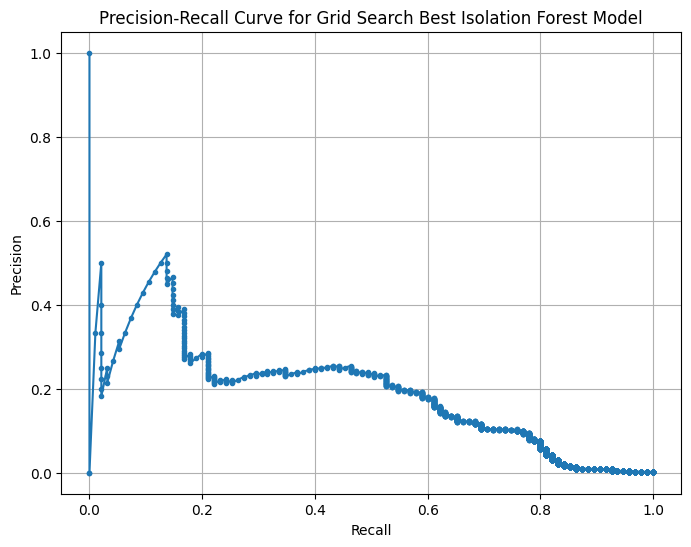

AUPRC (Area Under Precision-Recall Curve) for Grid Search Best Model: 0.1888


In [13]:
from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay

# Get the anomaly scores from the best Isolation Forest model
# anomaly_scores_test were already computed from grid.best_estimator_.decision_function(loaded_X_test)
# and inverted to match our convention (higher score = more anomalous)

# Calculate precision and recall for all possible thresholds for the best estimator
precision_gs, recall_gs, thresholds_gs = precision_recall_curve(loaded_y_test, anomaly_scores_test)

# Plot the Precision-Recall curve for the best estimator
plt.figure(figsize=(8, 6))
plt.plot(recall_gs, precision_gs, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Grid Search Best Isolation Forest Model')
plt.grid(True)
plt.show()

# Calculate and print the AUPRC score for the best estimator
auprc_gs = auc(recall_gs, precision_gs)
print(f"AUPRC (Area Under Precision-Recall Curve) for Grid Search Best Model: {auprc_gs:.4f}")